In [2]:
import sys
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score ,recall_score ,precision_score
sys.path.append(str(Path("..")))
from src.dataset import train_data, train_loader,train_path,train_indices,val_indices, val_loader, ood_loader,ood_path 
from torchvision import transforms,datasets
from torch.utils.data import Subset,DataLoader
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print(device)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

cuda
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [4]:
class CNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 32 * 32, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x


num_classes = len(train_data.classes)

model = CNN(num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

num_epochs = 100

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

val_f1_scores = []
val_precision_scores = []
val_recall_scores = []

val_f1_scores_by_class = []
val_precision_scores_by_class = []
val_recall_scores_by_class = []

best_val_f1 = 0.0
best_epoch = 0

for epoch in range(num_epochs):


    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()

    train_loss = running_train_loss / len(train_loader)

    train_accuracy = train_correct / train_total




    model.eval()

    running_val_loss = 0.0

    val_correct = 0
    val_total = 0

    all_val_labels = []
    all_val_predictions = []


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_val_loss += loss.item()


            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


            all_val_labels.extend(
                labels.cpu().numpy()
            )

            all_val_predictions.extend(
                predicted.cpu().numpy()
            )


    val_loss = (
        running_val_loss /
        len(val_loader)
    )

    val_accuracy = (
        val_correct /
        val_total
    )

    val_f1 = f1_score(
        all_val_labels,
        all_val_predictions,
        average="macro",
        zero_division=0
    )

    val_precision = precision_score(
        all_val_labels,
        all_val_predictions,
        average="macro",
        zero_division=0
    )

    val_recall = recall_score(
        all_val_labels,
        all_val_predictions,
        average="macro",
        zero_division=0
    )


    f1_score_by_class = f1_score(
        all_val_labels,
        all_val_predictions,
        average=None,
        zero_division=0
    )

    precision_by_class = precision_score(
        all_val_labels,
        all_val_predictions,
        average=None,
        zero_division=0
    )

    recall_by_class = recall_score(
        all_val_labels,
        all_val_predictions,
        average=None,
        zero_division=0
    )




    train_losses.append(
        train_loss
    )

    train_accuracies.append(
        train_accuracy
    )

    val_losses.append(
        val_loss
    )

    val_accuracies.append(
        val_accuracy
    )

    val_f1_scores.append(
        val_f1
    )

    val_precision_scores.append(
        val_precision
    )

    val_recall_scores.append(
        val_recall
    )

    val_f1_scores_by_class.append(
        f1_score_by_class
    )

    val_precision_scores_by_class.append(
        precision_by_class
    )

    val_recall_scores_by_class.append(
        recall_by_class
    )


    print(
        f"Epoch [{epoch + 1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val Precision: {val_precision:.4f} | "
        f"Val Recall: {val_recall:.4f} | "
        f"Val Macro F1: {val_f1:.4f}"
    )

    print("Precision by each class:")
    print(precision_by_class)

    print("Recall by each class:")
    print(recall_by_class)

    print("F1 Score by each class:")
    print(f1_score_by_class)
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            "../models/dropout_03.pth"
        )

        print(
        f"Best model saved! "
        f"Epoch: {best_epoch} | "
        f"Val Macro F1: {best_val_f1:.4f}"
        )



Epoch [1/100] | Train Loss: 1.5891 | Train Acc: 0.4620 | Val Loss: 1.0049 | Val Acc: 0.6753 | Val Precision: 0.7300 | Val Recall: 0.6212 | Val Macro F1: 0.6140
Precision by each class:
[0.57522124 0.84848485 0.62962963 0.51824818 0.77333333 0.67153285
 0.82352941 1.        ]
Recall by each class:
[0.8125     0.53846154 0.53125    0.64545455 0.63043478 0.82882883
 0.91588785 0.06666667]
F1 Score by each class:
[0.67357513 0.65882353 0.57627119 0.57489879 0.69461078 0.74193548
 0.86725664 0.125     ]
Best model saved! Epoch: 1 | Val Macro F1: 0.6140
Epoch [2/100] | Train Loss: 0.7335 | Train Acc: 0.7476 | Val Loss: 0.5914 | Val Acc: 0.8055 | Val Precision: 0.8143 | Val Recall: 0.7621 | Val Macro F1: 0.7708
Precision by each class:
[0.75824176 0.92941176 0.82051282 0.688      0.81111111 0.77037037
 0.90350877 0.83333333]
Recall by each class:
[0.8625     0.75961538 0.66666667 0.78181818 0.79347826 0.93693694
 0.96261682 0.33333333]
F1 Score by each class:
[0.80701754 0.83597884 0.73563218

In [5]:

num_classes = len(train_data.classes)

model = CNN(num_classes)
model = model.to(device)

model.load_state_dict(
    torch.load("../models/dropout_03.pth")
)

model = model.to(device)

In [6]:
model.eval()

all_val_labels = []

all_val_predictions = []

all_probabilities = []

all_logits = []

val_correct = 0

val_total = 0


classes = train_data.classes


truck_id = classes.index("kamyun")

truckette_id = classes.index("kamyunet")

van_id = classes.index("vanet")


with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        labels = labels.to(device)


        outputs = model(images)


        probabilities = torch.softmax(outputs,dim=1)

        _, predicted = torch.max(outputs,1)
        
        val_total += labels.size(0)

        val_correct += (predicted == labels).sum().item()


        all_val_labels.extend(labels.cpu().numpy())

        all_val_predictions.extend(predicted.cpu().numpy())

        all_probabilities.extend(probabilities.cpu().numpy())

        all_logits.extend(outputs.cpu().numpy())


val_accuracy = val_correct / val_total


val_precision = precision_score(
    all_val_labels,
    all_val_predictions,
    average="macro",
    zero_division=0
)


val_recall = recall_score(
    all_val_labels,
    all_val_predictions,
    average="macro",
    zero_division=0
)


val_f1 = f1_score(
    all_val_labels,
    all_val_predictions,
    average="macro",
    zero_division=0
)


val_precision_by_class = precision_score(
    all_val_labels,
    all_val_predictions,
    average=None,
    zero_division=0
)


val_recall_by_class = recall_score(
    all_val_labels,
    all_val_predictions,
    average=None,
    zero_division=0
)


val_f1_by_class = f1_score(
    all_val_labels,
    all_val_predictions,
    average=None,
    zero_division=0
)
print(f"val Accuracy: {val_accuracy:.4f}")


print(
    f"val Macro Precision: "
    f"{val_precision:.4f}"
)

print(
    f"val Macro Recall: "
    f"{val_recall:.4f}"
)

print(
    f"val Macro F1: "
    f"{val_f1:.4f}"
)


print("val Precision by class:")
print(val_precision_by_class)

print("val Recall by class:")
print(val_recall_by_class)

print("val F1 by class:")
print(val_f1_by_class)

val Accuracy: 0.8863
val Macro Precision: 0.8776
val Macro Recall: 0.8755
val Macro F1: 0.8764
val Precision by class:
[0.89285714 0.94       0.82105263 0.80869565 0.85714286 0.93636364
 0.97169811 0.79310345]
val Recall by class:
[0.9375     0.90384615 0.8125     0.84545455 0.84782609 0.92792793
 0.96261682 0.76666667]
val F1 by class:
[0.91463415 0.92156863 0.81675393 0.82666667 0.85245902 0.9321267
 0.96713615 0.77966102]


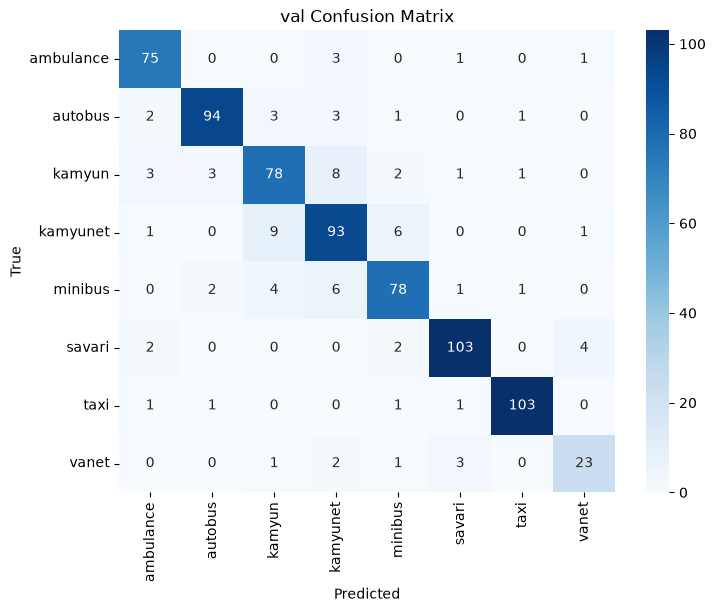

In [7]:
cm = confusion_matrix(
    all_val_labels,
    all_val_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_data.classes,
    yticklabels=train_data.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("val Confusion Matrix")

plt.show()

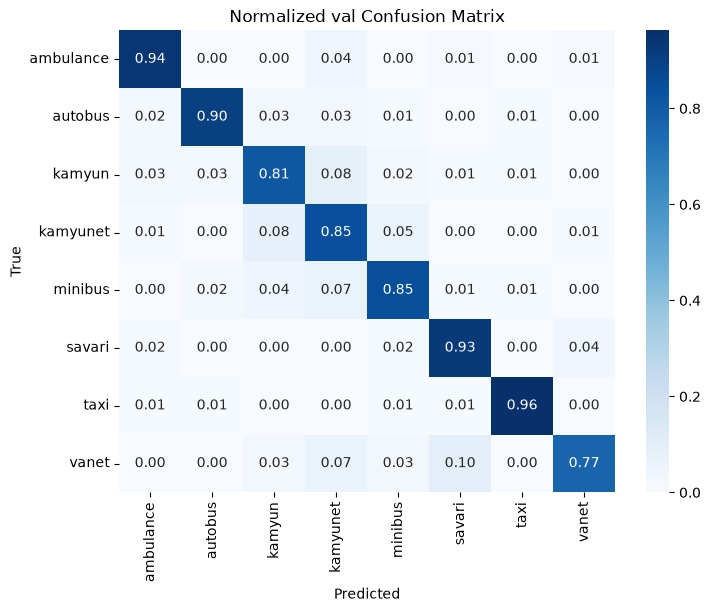

In [8]:
cm_normalized = confusion_matrix(
    all_val_labels,
    all_val_predictions,
    normalize="true"
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=train_data.classes,
    yticklabels=train_data.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized val Confusion Matrix")

plt.show()

# *DropOut 0.5*

In [9]:
class CNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 32 * 32, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x


num_classes = len(train_data.classes)

model = CNN(num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

num_epochs = 100

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

val_f1_scores = []
val_precision_scores = []
val_recall_scores = []

val_f1_scores_by_class = []
val_precision_scores_by_class = []
val_recall_scores_by_class = []

best_val_f1 = 0.0
best_epoch = 0

for epoch in range(num_epochs):


    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()

    train_loss = running_train_loss / len(train_loader)

    train_accuracy = train_correct / train_total




    model.eval()

    running_val_loss = 0.0

    val_correct = 0
    val_total = 0

    all_val_labels = []
    all_val_predictions = []


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_val_loss += loss.item()


            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


            all_val_labels.extend(
                labels.cpu().numpy()
            )

            all_val_predictions.extend(
                predicted.cpu().numpy()
            )


    val_loss = (
        running_val_loss /
        len(val_loader)
    )

    val_accuracy = (
        val_correct /
        val_total
    )

    val_f1 = f1_score(
        all_val_labels,
        all_val_predictions,
        average="macro",
        zero_division=0
    )

    val_precision = precision_score(
        all_val_labels,
        all_val_predictions,
        average="macro",
        zero_division=0
    )

    val_recall = recall_score(
        all_val_labels,
        all_val_predictions,
        average="macro",
        zero_division=0
    )


    f1_score_by_class = f1_score(
        all_val_labels,
        all_val_predictions,
        average=None,
        zero_division=0
    )

    precision_by_class = precision_score(
        all_val_labels,
        all_val_predictions,
        average=None,
        zero_division=0
    )

    recall_by_class = recall_score(
        all_val_labels,
        all_val_predictions,
        average=None,
        zero_division=0
    )




    train_losses.append(
        train_loss
    )

    train_accuracies.append(
        train_accuracy
    )

    val_losses.append(
        val_loss
    )

    val_accuracies.append(
        val_accuracy
    )

    val_f1_scores.append(
        val_f1
    )

    val_precision_scores.append(
        val_precision
    )

    val_recall_scores.append(
        val_recall
    )

    val_f1_scores_by_class.append(
        f1_score_by_class
    )

    val_precision_scores_by_class.append(
        precision_by_class
    )

    val_recall_scores_by_class.append(
        recall_by_class
    )


    print(
        f"Epoch [{epoch + 1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val Precision: {val_precision:.4f} | "
        f"Val Recall: {val_recall:.4f} | "
        f"Val Macro F1: {val_f1:.4f}"
    )

    print("Precision by each class:")
    print(precision_by_class)

    print("Recall by each class:")
    print(recall_by_class)

    print("F1 Score by each class:")
    print(f1_score_by_class)
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            "../models/dropout_05.pth"
        )

        print(
        f"Best model saved! "
        f"Epoch: {best_epoch} | "
        f"Val Macro F1: {best_val_f1:.4f}"
        )



Epoch [1/100] | Train Loss: 1.6831 | Train Acc: 0.4394 | Val Loss: 1.0170 | Val Acc: 0.6288 | Val Precision: 0.7045 | Val Recall: 0.5731 | Val Macro F1: 0.5554
Precision by each class:
[0.69135802 0.59701493 0.77777778 0.46551724 0.53       0.67826087
 0.89622642 1.        ]
Recall by each class:
[0.7        0.76923077 0.14583333 0.73636364 0.57608696 0.7027027
 0.88785047 0.06666667]
F1 Score by each class:
[0.69565217 0.67226891 0.24561404 0.57042254 0.55208333 0.69026549
 0.89201878 0.125     ]
Best model saved! Epoch: 1 | Val Macro F1: 0.5554
Epoch [2/100] | Train Loss: 0.9888 | Train Acc: 0.6572 | Val Loss: 0.7152 | Val Acc: 0.7671 | Val Precision: 0.7802 | Val Recall: 0.7418 | Val Macro F1: 0.7542
Precision by each class:
[0.9047619  0.82857143 0.69791667 0.66666667 0.73809524 0.66447368
 0.97959184 0.76190476]
Recall by each class:
[0.7125     0.83653846 0.69791667 0.67272727 0.67391304 0.90990991
 0.89719626 0.53333333]
F1 Score by each class:
[0.7972028  0.83253589 0.69791667 

In [10]:

num_classes = len(train_data.classes)

model = CNN(num_classes)
model = model.to(device)

model.load_state_dict(
    torch.load("../models/dropout_05.pth")
)

model = model.to(device)

In [11]:
model.eval()

all_val_labels = []

all_val_predictions = []

all_probabilities = []

all_logits = []

val_correct = 0

val_total = 0


classes = train_data.classes


truck_id = classes.index("kamyun")

truckette_id = classes.index("kamyunet")

van_id = classes.index("vanet")


with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        labels = labels.to(device)


        outputs = model(images)


        probabilities = torch.softmax(outputs,dim=1)

        _, predicted = torch.max(outputs,1)
        
        val_total += labels.size(0)

        val_correct += (predicted == labels).sum().item()


        all_val_labels.extend(labels.cpu().numpy())

        all_val_predictions.extend(predicted.cpu().numpy())

        all_probabilities.extend(probabilities.cpu().numpy())

        all_logits.extend(outputs.cpu().numpy())


val_accuracy = val_correct / val_total


val_precision = precision_score(
    all_val_labels,
    all_val_predictions,
    average="macro",
    zero_division=0
)


val_recall = recall_score(
    all_val_labels,
    all_val_predictions,
    average="macro",
    zero_division=0
)


val_f1 = f1_score(
    all_val_labels,
    all_val_predictions,
    average="macro",
    zero_division=0
)


val_precision_by_class = precision_score(
    all_val_labels,
    all_val_predictions,
    average=None,
    zero_division=0
)


val_recall_by_class = recall_score(
    all_val_labels,
    all_val_predictions,
    average=None,
    zero_division=0
)


val_f1_by_class = f1_score(
    all_val_labels,
    all_val_predictions,
    average=None,
    zero_division=0
)
print(f"val Accuracy: {val_accuracy:.4f}")


print(
    f"val Macro Precision: "
    f"{val_precision:.4f}"
)

print(
    f"val Macro Recall: "
    f"{val_recall:.4f}"
)

print(
    f"val Macro F1: "
    f"{val_f1:.4f}"
)


print("val Precision by class:")
print(val_precision_by_class)

print("val Recall by class:")
print(val_recall_by_class)

print("val F1 by class:")
print(val_f1_by_class)

val Accuracy: 0.8795
val Macro Precision: 0.8780
val Macro Recall: 0.8669
val Macro F1: 0.8709
val Precision by class:
[0.86585366 0.87387387 0.8045977  0.77952756 0.89534884 0.98039216
 0.97222222 0.85185185]
val Recall by class:
[0.8875     0.93269231 0.72916667 0.9        0.83695652 0.9009009
 0.98130841 0.76666667]
val F1 by class:
[0.87654321 0.90232558 0.76502732 0.83544304 0.86516854 0.93896714
 0.97674419 0.80701754]


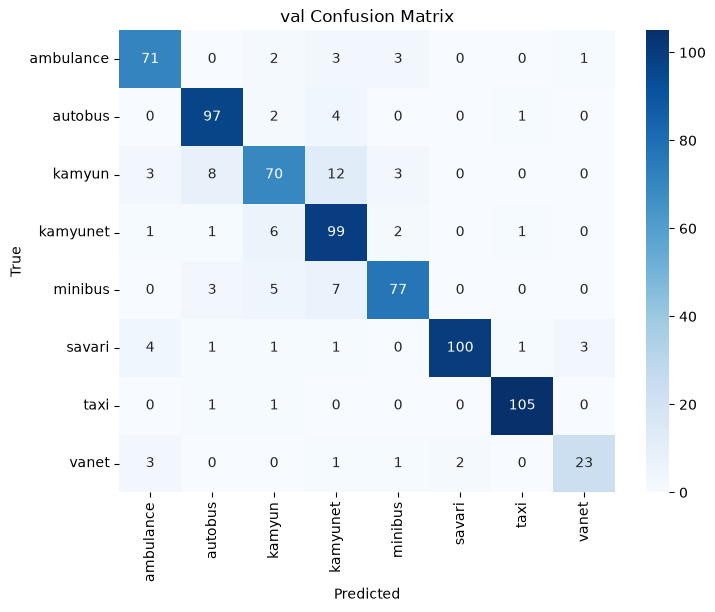

In [12]:
cm = confusion_matrix(
    all_val_labels,
    all_val_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_data.classes,
    yticklabels=train_data.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("val Confusion Matrix")

plt.show()

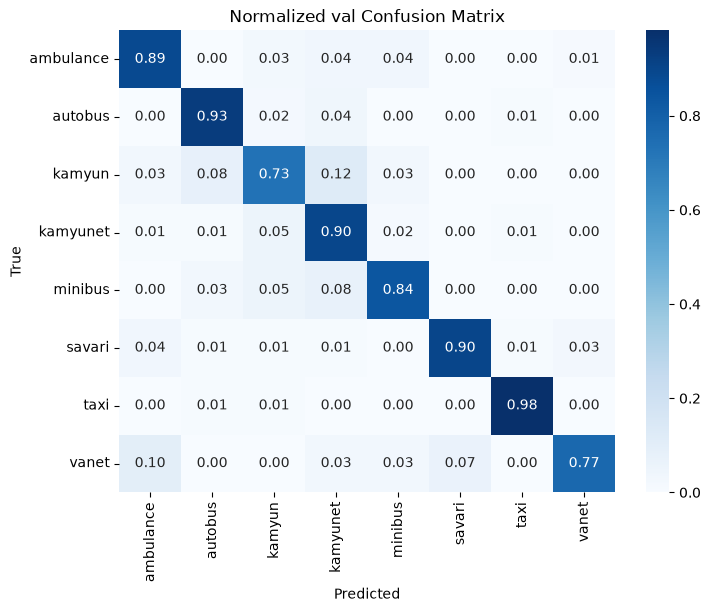

In [13]:
cm_normalized = confusion_matrix(
    all_val_labels,
    all_val_predictions,
    normalize="true"
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=train_data.classes,
    yticklabels=train_data.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized val Confusion Matrix")

plt.show()